# Limpieza Exploratoria de Datos (EDA & Data Wrangling)

En este notebook vamos a explorar la muestra inicial de propiedades descargadas (propiedades_raw.csv) para diseñar las reglas de limpieza que aplicaremos masivamente a los 5.000 pisos.

In [3]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Cargar los datos crudos
df_raw = pd.read_csv('../data_pipeline/data/raw/propiedades_raw.csv')

print(f'Propiedades cargadas: {len(df_raw)}')
df_raw[['precio', 'm2', 'habitaciones', 'banos', 'planta']].head(3)

Propiedades cargadas: 5339


,precio,m2,habitaciones,banos,planta
0,7.000.000 €,233.0,2.0,4.0,1ª
1,730.000 €\n20.000 € (-3%),91.0,2.0,1.0,1ª
2,362.000 €,94.0,3.0,2.0,4ª


## 1. Limpieza del Precio
A veces el precio viene con rebajas en varias líneas, ej: 730.000 €\n20.000 € (-3%). Queremos quedarnos solo con el primer valor numérico (el precio actual).

In [4]:
def clean_price(price_str):
    if pd.isna(price_str) or str(price_str).lower() in ['consultar', 'precio a consultar']:
        return np.nan
    # Quedarnos con la primera linea (el precio actual, ignorando el precio anterior tachado)
    precio_principal = str(price_str).split('\n')[0]
    # Extraer solo los numeros
    nums = re.sub(r'[^0-9]', '', precio_principal)
    return int(nums) if nums else np.nan

df_raw['precio_limpio'] = df_raw['precio'].apply(clean_price)
df_raw[['precio', 'precio_limpio']].head()

,precio,precio_limpio
0,7.000.000 €,7000000.0
1,730.000 €\n20.000 € (-3%),730000.0
2,362.000 €,362000.0
3,350.000 €\n19.000 € (-5%),350000.0
4,230.000 €,230000.0


## 2. Limpieza de Planta
La planta viene como texto (ej. 1º, Bajo). Vamos a pasarlo a numérico (Bajo=0). Las variables m2, habitaciones y anos ya vienen limpias de origen gracias a nuestro scraper.

In [5]:
def clean_planta(planta_str):
    if pd.isna(planta_str):
        return np.nan
    planta_str = str(planta_str).lower().strip()
    if 'bajo' in planta_str or 'bj' in planta_str:
        return 0.0
    if 'entresuelo' in planta_str:
        return 0.5
    if 'sotano' in planta_str or 'sótano' in planta_str:
        return -1.0
    
    # Buscar primer numero
    match = re.search(r'\d+', planta_str)
    if match:
        return float(match.group())
    return np.nan

df_raw['planta_limpia'] = df_raw['planta'].apply(clean_planta)
df_raw[['planta', 'planta_limpia']].head(10)

,planta,planta_limpia
0,1ª,1.0
1,1ª,1.0
2,4ª,4.0
3,NaN,NaN
4,1ª,1.0
5,2ª,2.0
6,NaN,NaN
7,NaN,NaN
8,4ª,4.0
9,NaN,NaN


## 3. Extraccion del Tipo de Inmueble
En el modelo predictivo, un Chalet no vale lo mismo que un Piso. Podemos extraer el tipo exacto leyendo la primera palabra del `titulo` (ej. Piso, Atico, Duplex, Chalet, Estudio).

In [6]:
def extract_tipo(titulo):
    if pd.isna(titulo): return "Desconocido"
    # Extraer la primera palabra antes de "en venta"
    import re
    match = re.match(r"^([A-Za-zÁÉÍÓÚáéíóúÑñ]+)\s+en\s+venta", str(titulo), re.IGNORECASE)
    if match:
        return match.group(1).title()
    return "Piso"

df_raw['tipo_inmueble'] = df_raw['titulo'].apply(extract_tipo)
df_raw[['titulo', 'tipo_inmueble']].head()

,titulo,tipo_inmueble
0,Piso en venta en Calle de Sagasta en Trafalgar...,Piso
1,"Piso en venta en Calle de Azcona, cerca de Cal...",Piso
2,"Piso en venta en Avenida de Pablo Neruda, cerc...",Piso
3,Piso en venta en Calle de Nuestra Señora de Ar...,Piso
4,Piso en venta en Calle de los Dibujantes en Ar...,Piso


## 4. Feature Engineering: Precio por Metro Cuadrado
Esta es la metrica de oro en Real Estate. La calculamos dividiendo el precio limpio entre los metros cuadrados extraidos.

In [7]:
# Asegurarnos de que el precio y m2 son numericos
df_raw['precio_limpio'] = pd.to_numeric(df_raw['precio_limpio'], errors="coerce")
df_raw['m2'] = pd.to_numeric(df_raw['m2'], errors="coerce")

df_raw['precio_m2'] = df_raw['precio_limpio'] / df_raw['m2']
df_raw['precio_m2'] = df_raw['precio_m2'].round(2)
df_raw[['precio_limpio', 'm2', 'precio_m2']].head()

,precio_limpio,m2,precio_m2
0,7000000.0,233.0,30042.92
1,730000.0,91.0,8021.98
2,362000.0,94.0,3851.06
3,350000.0,75.0,4666.67
4,230000.0,61.0,3770.49


## 5. Limpieza Textual (Descripcion y Barrio)
Es vital quitar espacios extra, saltos de linea molestos y normalizar textos para que luego los modelos NLP/LLM no se confundan.

In [8]:
def clean_text(text):
    if pd.isna(text): return ""
    # Quitar saltos de linea y espacios multiples
    import re
    text = re.sub(r"\s+", " ", str(text))
    return text.strip()

df_raw['descripcion_limpia'] = df_raw['descripcion'].apply(clean_text)
df_raw['barrio_limpio'] = df_raw['barrio'].apply(clean_text).str.title()

print("ANTES:", repr(df_raw['descripcion'].iloc[0][:100]))
print("DESPUES:", repr(df_raw['descripcion_limpia'].iloc[0][:100]))

ANTES: 'Única Inmobiliaria presenta este proyecto de interiorismo de 233m2 en el que los materiales y las pi'
DESPUES: 'Única Inmobiliaria presenta este proyecto de interiorismo de 233m2 en el que los materiales y las pi'


## 6. Preprocesamiento Avanzado para Machine Learning

Una vez que el dataset está "matemáticamente limpio", necesitamos hacerle una última traducción antes de pasarlo a la red neuronal o al modelo matemático. A esto se le llama **Data Preprocessing**.

### 6.1. Transformación Categórica (One-Hot Encoding)
Los modelos matemáticos (como Random Forest o Redes Neuronales) no pueden multiplicar ni sumar la palabra `"Ático"` o `"Chamberí"`. Necesitamos convertir esos textos en una matriz de 1s y 0s. Por ejemplo, si tenemos 5 tipos de pisos, crearemos 5 columnas nuevas y pondremos un `1` en la columna que le corresponda a cada casa.

In [9]:
# Volvemos a cargar el dataset ahora que ya esta filtrado por el script 3_data_cleaner.py
df_clean = pd.read_csv('../data_pipeline/data/processed/propiedades_limpias.csv')

# Vemos cuantos valores unicos hay en la columna original
print("--- Valores de Tipo de Inmueble Original ---")
print(df_clean['tipo_inmueble'].value_counts().head(3))
print("\n")

# Aplicamos One-Hot Encoding con Pandas (get_dummies)
df_onehot = pd.get_dummies(df_clean, columns=['tipo_inmueble'])

# Mostramos como han quedado las nuevas columnas (1=True, 0=False)
columnas_generadas = [c for c in df_onehot.columns if 'tipo_inmueble_' in c]
df_onehot[columnas_generadas].head()

--- Valores de Tipo de Inmueble Original ---
tipo_inmueble
Piso           4146
Apartamento     284
Ático           236
Name: count, dtype: int64




,tipo_inmueble_Apartamento,tipo_inmueble_Casa,tipo_inmueble_Chalet,tipo_inmueble_Dúplex,tipo_inmueble_Estudio,tipo_inmueble_Loft,tipo_inmueble_Piso,tipo_inmueble_Ático
0,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,True,False


### 6.2. Estabilización de la Distribución del Precio (Log-Transform)
Los precios inmobiliarios sufren de asimetría positiva (*Right Skew*). Esto significa que la mayoría de casas cuestan entre 200k y 600k, pero hay unas pocas mansiones de 10 Millones de euros. Si le pasamos los euros directamente a la IA, su cálculo de "error" se volverá inestable intentando ajustar la curva a los multimillonarios.

Para suavizarlo, le aplicamos una transformación logarítmica matemática (`np.log1p`), que comprime los valores gigantes pero mantiene las proporciones reales.

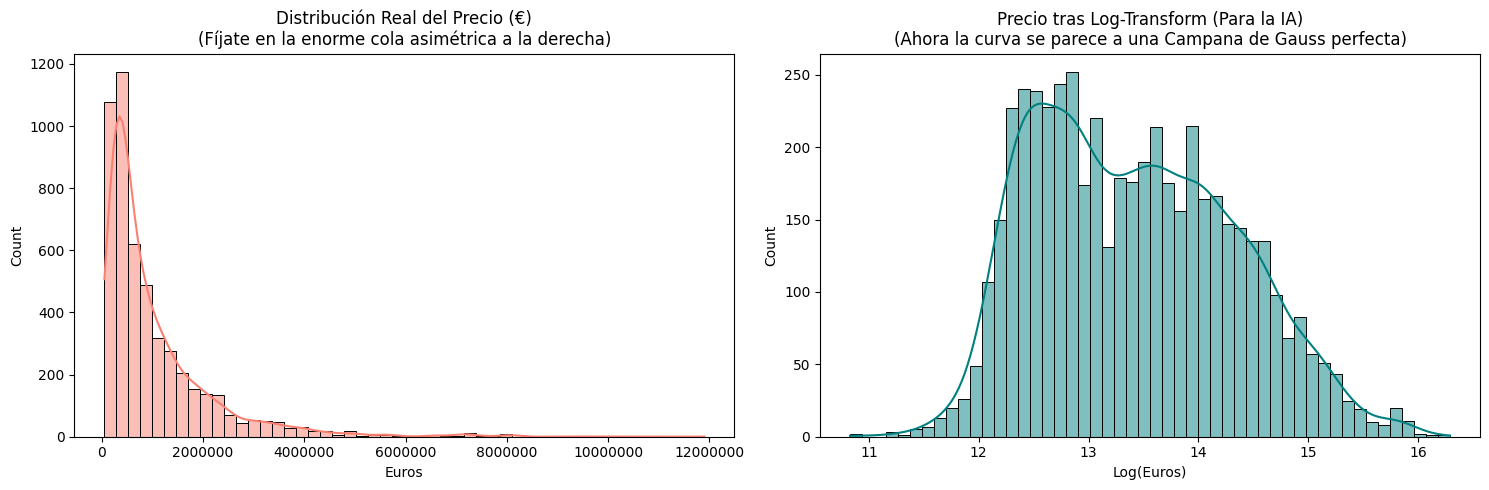

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafica 1: Precios crudos
sns.histplot(df_clean['precio_limpio'], bins=50, kde=True, ax=axes[0], color='salmon')
axes[0].set_title("Distribución Real del Precio (€)\n(Fíjate en la enorme cola asimétrica a la derecha)")
axes[0].set_xlabel("Euros")
axes[0].ticklabel_format(style='plain', axis='x')

# Aplicamos logaritmo natural
df_clean['precio_log'] = np.log1p(df_clean['precio_limpio'])

# Grafica 2: Precios tras el Logaritmo
sns.histplot(df_clean['precio_log'], bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title("Precio tras Log-Transform (Para la IA)\n(Ahora la curva se parece a una Campana de Gauss perfecta)")
axes[1].set_xlabel("Log(Euros)")

plt.tight_layout()
plt.show()

### 6.3. Transformación y Estandarización de Imágenes (Para la CNN)

En PyTorch (como puedes ver en tu archivo `model_training/dataset.py`), una red neuronal convolucional no puede ingerir imágenes de tamaños aleatorios. Las cámaras echan fotos en vertical, horizontal, a 4K o a 720p. 

Antes de dárselas a PyTorch, aplicamos un "pipeline de transformación" que hace 3 cosas críticas de forma obligatoria:
1. **Resize(224, 224)**: Aplasta, estira o recorta todas las imágenes para que sean cuadraditos perfectos de 224x224 píxeles (el tamaño estándar mundial exigido por la arquitectura *ResNet50*).
2. **ToTensor**: Convierte la foto (mapa de píxeles) a un tensor matemático 3D de números entre 0 y 1.
3. **Normalize**: Le aplica una estandarización de color basada en el estándar *ImageNet* para que los pesos de la red preentrenada funcionen.

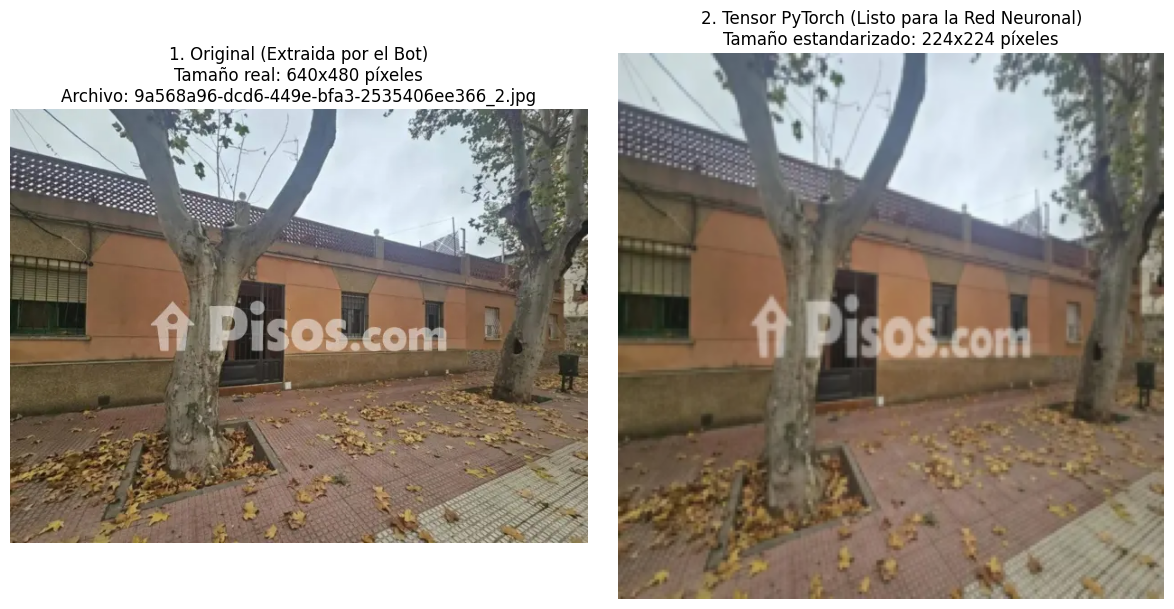

-> Dimensiones matemáticas del Tensor: torch.Size([3, 224, 224])
-> Los colores ahora son decimales entre 0 y 1. Ejemplo de valor: 0.7647


In [11]:
from PIL import Image
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import random

# Simulamos la transformacion exacta que ya tienes programada en tu dataset.py
cnn_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Elegir una imagen aleatoria cada vez que se ejecute la celda
image_dir = '../data_pipeline/data/raw/images'
todas_las_fotos = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if not todas_las_fotos:
    print("No se encontraron imagenes en el directorio.")
else:
    foto_aleatoria = random.choice(todas_las_fotos)
    test_image_path = os.path.join(image_dir, foto_aleatoria)

    try:
        img_original = Image.open(test_image_path).convert('RGB')
        tensor_final = cnn_transform(img_original)
        
        # Preparamos el grafico doble
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        
        # 1. Imagen Original
        axes[0].imshow(img_original)
        axes[0].set_title(f"1. Original (Extraida por el Bot)\nTamaño real: {img_original.size[0]}x{img_original.size[1]} píxeles\nArchivo: {foto_aleatoria}")
        axes[0].axis('off')
        
        # 2. Tensor Transformado (PyTorch)
        # PyTorch guarda las imagenes como (Canales, Alto, Ancho)
        # Matplotlib necesita (Alto, Ancho, Canales), asi que usamos permute()
        img_pytorch = tensor_final.permute(1, 2, 0).numpy()
        
        axes[1].imshow(img_pytorch)
        axes[1].set_title(f"2. Tensor PyTorch (Listo para la Red Neuronal)\nTamaño estandarizado: 224x224 píxeles")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"-> Dimensiones matemáticas del Tensor: {tensor_final.shape}")
        print(f"-> Los colores ahora son decimales entre 0 y 1. Ejemplo de valor: {tensor_final[0][0][0].item():.4f}")
        
    except Exception as e:
        print(f"Error al cargar o procesar la imagen: {e}")

## 4. Filtro Zero-Shot con IA (Solucionando el "Garbage In, Garbage Out")

Al hacer scraping web, descargamos accidentalmente imágenes que NO son interiores de viviendas (logotipos de inmobiliarias, planos arquitectónicos en 2D, o fotografías de parques y calles cercanas). Si alimentamos nuestra CNN con esto, destrozaremos su precisión.

A continuación, utilizamos el modelo **CLIP (OpenAI)** para hacer una clasificación Zero-Shot y expulsar esta "basura" visual de nuestro conjunto de datos de entrenamiento.

Cargando modelo CLIP...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 10990.05it/s]


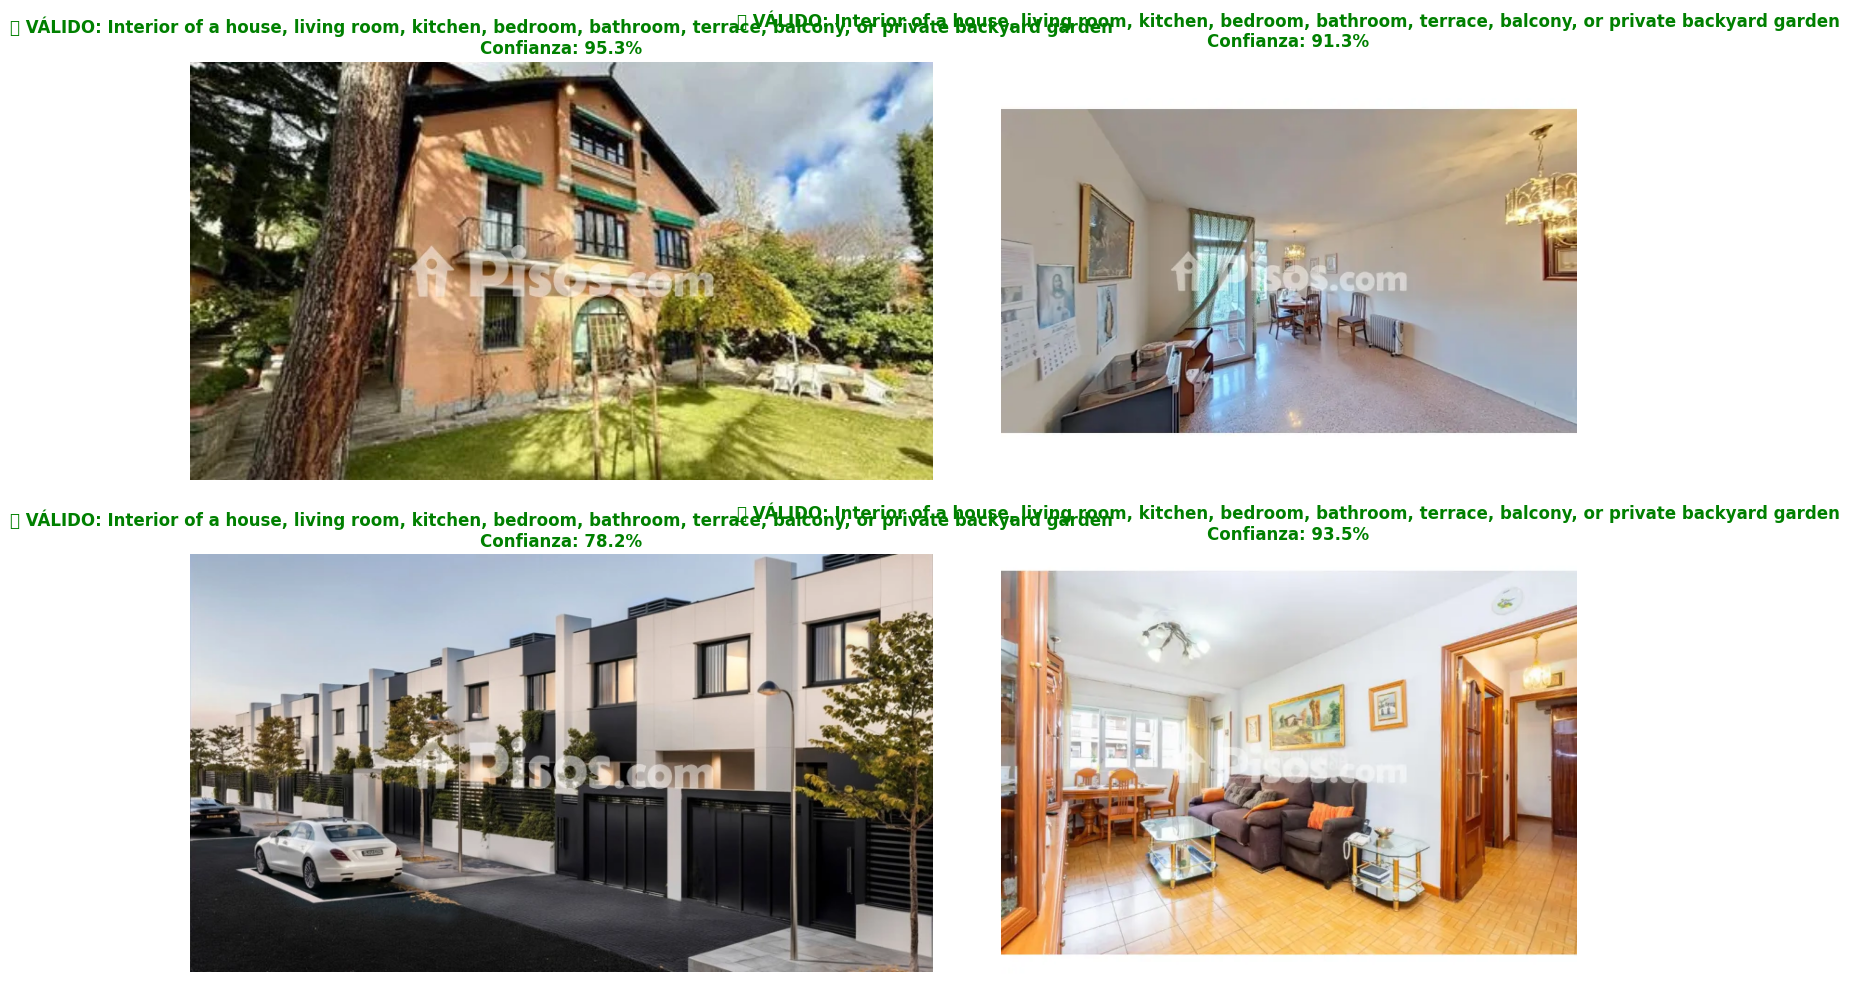

In [12]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import matplotlib.pyplot as plt
import os
import random

# 1. Cargamos el modelo CLIP
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Cargando modelo CLIP...")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# 2. Definimos las etiquetas de purga en inglés (para mayor precisión)
labels = [
    "Interior of a house, living room, kitchen, bedroom, bathroom, terrace, balcony, or private backyard garden", 
    "Exterior of a building, a public street, a public park, or nature", 
    "Architectural floor plan or 2D map", 
    "Commercial real estate agency logo", 
    "A photo of a community swimming pool, gym, or shared common area"
]

# 3. Cogemos 4 imágenes al azar
image_dir = '../data_pipeline/data/raw/images'
todas_las_fotos = [f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
muestras = random.sample(todas_las_fotos, 4)

# 4. Clasificamos y dibujamos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, img_name in enumerate(muestras):
    img_path = os.path.join(image_dir, img_name)
    image = Image.open(img_path).convert("RGB")
    
    # Inferencia matemática
    inputs = processor(text=labels, images=image, return_tensors="pt", padding=True).to(device)
    outputs = model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=1).detach().cpu().numpy()[0]
    
    best_idx = probs.argmax()
    confidence = probs[best_idx] * 100
    
    # Preparamos el color del titulo (Verde si es Interior, Rojo si es Basura)
    color = 'green' if best_idx == 0 else 'red'
    decision = "✅ VÁLIDO" if best_idx == 0 else "❌ PURGAR"
    
    axes[i].imshow(image)
    axes[i].set_title(f"{decision}: {labels[best_idx]}\nConfianza: {confidence:.1f}%", color=color, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()